In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import xclimate as xclim

In [2]:
# Variables to load
VARIABLES = [
    "TLAI_month_1",
    "RAIN_FROM_ATM_month_1",
    "EFLX_LH_TOT_month_1",
    "TSA_month_1",
]

# Time period for analysis
START_TIME = "1950-01"
END_TIME = "2014-12"

# Load grid
grid = xclim.load_fhist_ppe_grid().compute()

print(f"Loading variables from {START_TIME} to {END_TIME}...")
fhist = {}
ohist = {}

for v in VARIABLES:
    print(f"  Loading {v}...")
    name = "_".join(v.split("_")[:-2])

    fhist[v] = (
        xclim.load_fhist(v, keep_var_only=True)[name]
        .sel(lat=slice(-60, None), time=slice(START_TIME, END_TIME))
        .reindex_like(grid, method="nearest", tolerance=1e-3)
    )

    ohist[v] = (
        xclim.load_offlhist(v, keep_var_only=True)[name]
        .sel(lat=slice(-60, None), time=slice(START_TIME, END_TIME))
        .reindex_like(grid, method="nearest", tolerance=1e-3)
    )

Loading variables from 1950-01 to 2014-12...
  Loading TLAI_month_1...
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


  Loading RAIN_FROM_ATM_month_1...
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


...

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


  Loading TSA_month_1...
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


In [3]:
period_tm = slice("1995-01", "2014-12")

time_coord = fhist[list(fhist.keys())[0]].time.sel(time=period_tm)
dpm = time_coord.dt.days_in_month
weights = dpm.groupby('time.year') / dpm.groupby('time.year').sum()

fhist_diff = {}
ohist_diff = {}
for v in VARIABLES:
    fhist_tm = (fhist[v].sel(time=period_tm) * weights).groupby('time.year').sum().mean(dim='year')
    fhist_tm_zm = fhist_tm.mean(dim='lon')
    fhist_diff[v] = fhist_tm_zm.sel(member=slice(1, None)) - fhist_tm_zm.sel(member=0)
    fhist_diff[v] = fhist_diff[v].compute()

    ohist_tm = (ohist[v].sel(time=period_tm) * weights).groupby('time.year').sum().mean(dim='year')
    ohist_tm_zm = ohist_tm.mean(dim='lon')
    ohist_diff[v] = ohist_tm_zm.sel(member=slice(1, None)) - ohist_tm_zm.sel(member=0)
    ohist_diff[v] = ohist_diff[v].compute()

In [4]:
fhist_diff_gm = {}
ohist_diff_gm = {}
for v in VARIABLES:
    fhist_tm = (fhist[v].sel(time=period_tm) * weights).groupby('time.year').sum().mean(dim='year')
    fhist_tm_gm = fhist_tm.where(grid.PCT_GLC < 20).weighted(grid.LANDFRAC).mean(dim=['lat', 'lon'])
    fhist_diff_gm[v] = fhist_tm_gm.sel(member=slice(1, None)) - fhist_tm_gm.sel(member=0)
    fhist_diff_gm[v] = fhist_diff_gm[v].compute()

    ohist_tm = (ohist[v].sel(time=period_tm) * weights).groupby('time.year').sum().mean(dim='year')
    ohist_tm_gm = ohist_tm.where(grid.PCT_GLC < 20).weighted(grid.LANDFRAC).mean(dim=['lat', 'lon'])
    ohist_diff_gm[v] = ohist_tm_gm.sel(member=slice(1, None)) - ohist_tm_gm.sel(member=0)
    ohist_diff_gm[v] = ohist_diff_gm[v].compute()

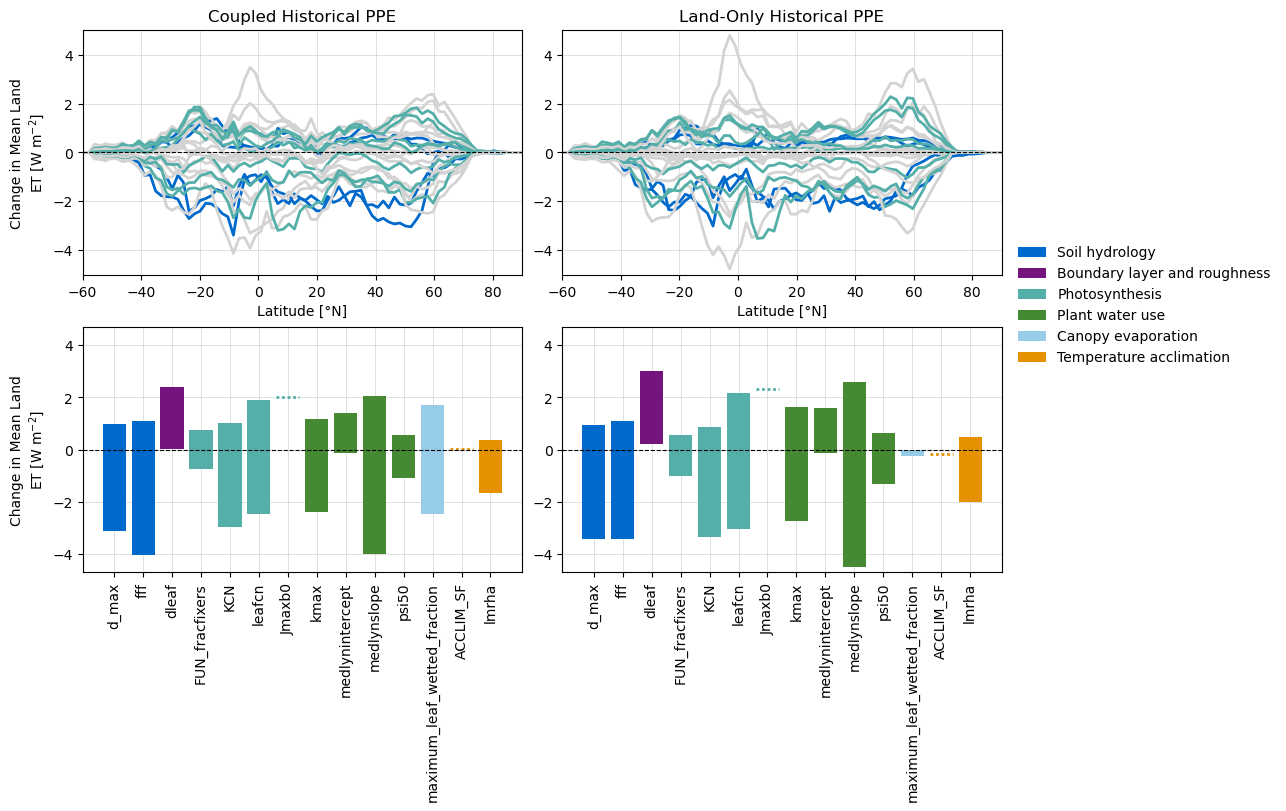

In [6]:
v = "EFLX_LH_TOT_month_1"
ylabel = "Change in Mean Land\nET [W m$^{-2}$]"

# v = "TSA_month_1"
# ylabel = "Change in Mean Land\nTemperature [\u00b0C]"

highlight_cats = ['sl', 'ps']
x_zm = fhist_diff[v]
x_gm = fhist_diff_gm[v]
y_zm = ohist_diff[v]
y_gm = ohist_diff_gm[v]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), layout='constrained')
axs = axes.ravel()

pcat_dict = xclim.ppe.load_member_cat_dict()
pcat_abbrv = pcat_dict['pcat_abbrv']
highlight_cats_long = [pcat_abbrv[p] for p in highlight_cats]

# Zonal mean
for m in x_zm.member:
    c = 'lightgray'
    catl = xclim.ppe.get_member_cat_name(m.values)
    if catl in highlight_cats_long:
        c = xclim.ppe.get_member_cat_color(m.values)
    x_zm.sel(member=m).plot(ax=axs[0], c=c, lw=2, _labels=False)

for m in y_zm.member:
    c = 'lightgray'
    catl = xclim.ppe.get_member_cat_name(m.values)
    if catl in highlight_cats_long:
        c = xclim.ppe.get_member_cat_color(m.values)
    y_zm.sel(member=m).plot(ax=axs[1], c=c, lw=2, _labels=False)

xy_zm_abs = max([abs(x_zm.max()), abs(y_zm.max())])
xy_zm_abs = xy_zm_abs * 1.05

# Bar plot
width = 0.8

# x_gm_xlabels = np.unique([xclim.ppe.get_member_info(i)[1] for i in x_gm.member.values])
x_gm_xlabels = [
    "d_max", "fff",
    "dleaf",
    "FUN_fracfixers", "KCN", "leafcn", "Jmaxb0",
    "kmax", "medlynintercept", "medlynslope", "psi50",
    "maximum_leaf_wetted_fraction",
    "ACCLIM_SF", "lmrha",
]
x_gm_colors = [pcat_dict['pname_color'][i] for i in x_gm_xlabels]
x_gm_xticks = np.arange(len(x_gm_xlabels))

# y_gm_xlabels = np.unique([xclim.ppe.get_member_info(i)[1] for i in y_gm.member.values])
y_gm_xlabels = x_gm_xlabels
y_gm_colors = [pcat_dict['pname_color'][i] for i in y_gm_xlabels]
y_gm_xticks = np.arange(len(y_gm_xlabels))

x_gm_paired = x_gm.assign_coords(
    param=(
        "member",
        [xclim.ppe.get_member_info(i)[1] for i in x_gm.member.values],
    ),
)
y_gm_paired = y_gm.assign_coords(
    param=(
        "member",
        [xclim.ppe.get_member_info(i)[1] for i in y_gm.member.values],
    ),
)

x_gm_bottoms = x_gm_paired.groupby('param').min().sel(param=x_gm_xlabels)
y_gm_bottoms = y_gm_paired.groupby('param').min().sel(param=x_gm_xlabels)

x_gm_tops = x_gm_paired.groupby('param').max().sel(param=x_gm_xlabels)
y_gm_tops = y_gm_paired.groupby('param').max().sel(param=x_gm_xlabels)

x_gm_heights = x_gm_tops - x_gm_bottoms
y_gm_heights = y_gm_tops - y_gm_bottoms

xy_gm_abs = max(
    [
        x_gm_tops.max(), y_gm_tops.max(),
        abs(x_gm_bottoms.min()), abs(y_gm_bottoms.min())
    ]
)
xy_gm_abs = xy_gm_abs * 1.05

for i, p in zip([12, 6], ['ACCLIM_SF', 'Jmaxb0']):
    axs[2].plot(
        [i-width/2, i+width/2],
        2*[x_gm_tops.sel(param=p)],
        color=x_gm_colors[i],
        lw=2,
        ls=(0, (1, 1)),
    )
    axs[3].plot(
        [i-width/2, i+width/2],
        2*[y_gm_tops.sel(param=p)],
        color=y_gm_colors[i],
        lw=2,
        ls=(0, (1, 1)),
    )

axs[2].bar(
    x=x_gm_xticks,
    height=x_gm_heights,
    bottom=x_gm_bottoms,
    color=x_gm_colors,
    width=width,
)

axs[3].bar(
    x=y_gm_xticks,
    height=y_gm_heights,
    bottom=y_gm_bottoms,
    color=y_gm_colors,
    width=width,
)

# Format axes
axs[0].set_title("Coupled Historical PPE")
axs[1].set_title("Land-Only Historical PPE")

for i in range(2):
    axs[i].set_ylim(-xy_zm_abs, xy_zm_abs)
    axs[i].axhline(0, c='k', lw=0.8, ls='--')
    axs[i].grid(c='lightgray', lw=0.5, ls='-')
    axs[i].set_xlim(-60, 90)
    axs[i].set_xlabel("Latitude [\u00b0N]")
    if i == 0:
        axs[i].set_ylabel(ylabel)
    
axs[2].set_xticks(x_gm_xticks)
axs[2].set_xticklabels(x_gm_xlabels, rotation=90)
axs[3].set_xticks(y_gm_xticks)
axs[3].set_xticklabels(y_gm_xlabels, rotation=90)

for i in range(2,4):
    axs[i].set_ylim(-xy_gm_abs, xy_gm_abs)
    axs[i].axhline(0, c='k', lw=0.8, ls='--')
    axs[i].set_axisbelow(True)
    axs[i].grid(c='lightgray', lw=0.5, ls='-', zorder=0)
    if i == 2:
        axs[i].set_ylabel(ylabel)
    
# for i, a in enumerate(['a', 'b', 'c', 'd']):
#     axs[i].set_title(f"({a})", loc='left')

# Create custom legend entries
legend_elements = []
for abbrv in ['sl', 'bl', 'ps', 'wu', 'ce', 'ta']:
    legend_elements.append(
        Patch(facecolor=pcat_dict['pcat_color'][abbrv], label=pcat_dict['pcat_abbrv'][abbrv])
    )
fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.625), frameon=False)

Text(0.5, 1.0, 'Zonal-mean $\\Delta$ET across FHIST PPE; time mean 1995-2014')

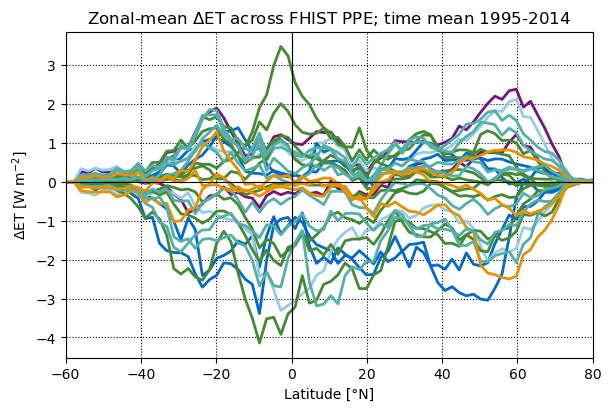

In [4]:
x = fhist_diff["EFLX_LH_TOT_month_1"]

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
for m in x.member:
    catc = xclim.ppe.get_member_cat_color(m.values)
    catl = xclim.ppe.get_member_cat_name(m.values)
    x.sel(member=m).plot(ax=ax, c=catc, lw=2)

ax.axhline(0, c='k', lw=0.8)
ax.axvline(0, c='k', lw=0.8)
ax.grid(c='k', lw=0.8, ls=':')
ax.set_xlim(-60, 80)

ax.set_ylabel("$\\Delta$ET [W m$^{-2}$]")
ax.set_xlabel("Latitude [\u00b0N]")
ax.set_title("Zonal-mean $\\Delta$ET across FHIST PPE; time mean 1995-2014")

Text(0.5, 1.0, 'Zonal-mean spread in $\\Delta$ET across OFFLHIST PPE; time mean 1995-2014')

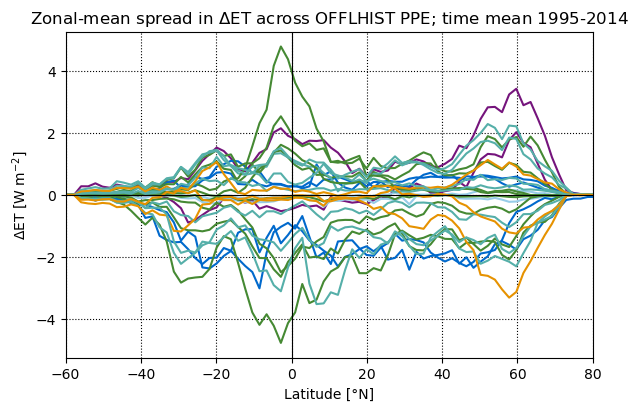

In [39]:
x = ohist_diff["EFLX_LH_TOT_month_1"]

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
for m in x.member:
    catc = xclim.ppe.get_member_cat_color(m.values)
    x.sel(member=m).plot(ax=ax, c=catc)

ax.axhline(0, c='k', lw=0.8)
ax.axvline(0, c='k', lw=0.8)
ax.grid(c='k', lw=0.8, ls=':')
ax.set_xlim(-60, 80)

ax.set_ylabel("$\\Delta$ET [W m$^{-2}$]")
ax.set_xlabel("Latitude [\u00b0N]")
ax.set_title("Zonal-mean spread in $\\Delta$ET across OFFLHIST PPE; time mean 1995-2014")

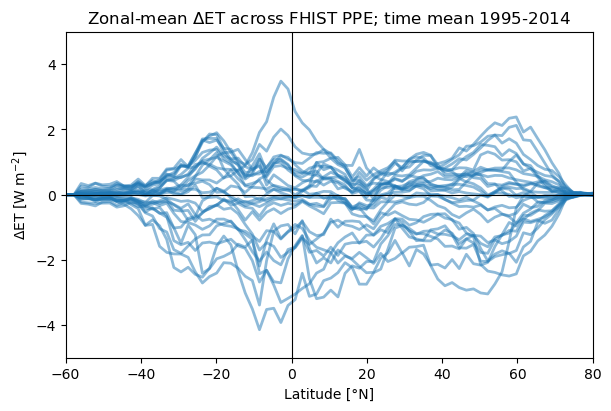

In [56]:
x = fhist_diff["EFLX_LH_TOT_month_1"]

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
for m in x.member:
    x.sel(member=m).plot(ax=ax, c='tab:blue', lw=2, alpha=0.5)

ax.axhline(0, c='k', lw=0.8)
ax.axvline(0, c='k', lw=0.8)
# ax.grid(c='k', lw=0.8, ls=':')
ax.set_xlim(-60, 80)
ax.set_ylim(-5, 5)

ax.set_ylabel("$\\Delta$ET [W m$^{-2}$]")
ax.set_xlabel("Latitude [\u00b0N]")
ax.set_title("Zonal-mean $\\Delta$ET across FHIST PPE; time mean 1995-2014")

fig.savefig("fig/for/abby/d.zonal.fhist.pdf", bbox_inches="tight", dpi=300)

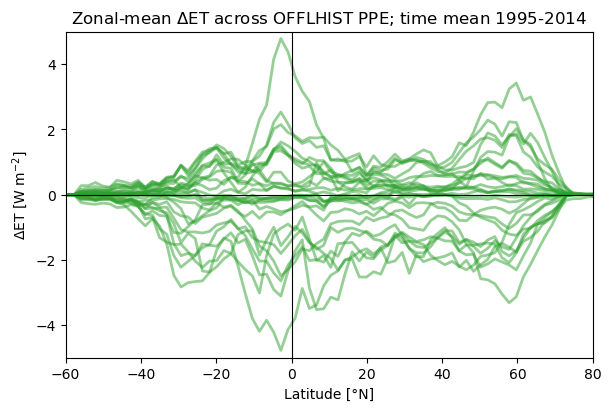

In [55]:
x = ohist_diff["EFLX_LH_TOT_month_1"]

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
for m in x.member:
    x.sel(member=m).plot(ax=ax, c='tab:green', lw=2, alpha=0.5)

ax.axhline(0, c='k', lw=0.8)
ax.axvline(0, c='k', lw=0.8)
# ax.grid(c='k', lw=0.8, ls=':')
ax.set_xlim(-60, 80)
ax.set_ylim(-5, 5)

ax.set_ylabel("$\\Delta$ET [W m$^{-2}$]")
ax.set_xlabel("Latitude [\u00b0N]")
ax.set_title("Zonal-mean $\\Delta$ET across OFFLHIST PPE; time mean 1995-2014")

fig.savefig("fig/for/abby/d.zonal.offlhist.pdf", bbox_inches="tight", dpi=300)